# nb05 -- Sparse shallow MLP: RNA -> protein
Per-protein relationship, not pairwise. All 2092 genes (matched + HVG union, from nb03) predict all 163 matched proteins jointly, with L1 sparsity forced on the input layer so only a subset of genes drive the hidden representation. This lets us check, per protein, whether the cognate RNA is actually the top predictor or whether something else (complex partner, tissue proxy) dominates.

Inputs are pre-totalVI normalized values (log1p CP10k for RNA, CLR for protein) -- deliberately not totalVI's denoised/batch-corrected outputs, to avoid training on another model's inferred structure.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Imports and config

In [3]:
!pip install -q -U "typing_extensions>=4.13"

In [4]:
!pip install -q scikit-misc

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'sparse_mlp'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM   = 64
L1_LAMBDA    = 1e-4
BATCH_SIZE   = 256
NUM_EPOCHS   = 100
PATIENCE     = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

## Load checkpoint and gene mapping
Same as nb03 -- splits GEX/ADT, rebuilds the 163-gene matched set from the saved mapping.

In [6]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Gene union (matched + HVG)
Same construction as nb03 -- matched coupling genes are always kept even if not top-variance.

In [7]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)} (matched-only additions: {len(set(matched_genes) - set(hvg_genes))})')

Gene union: 2092 (matched-only additions: 92)


## Normalize RNA and protein (pre-totalVI)
RNA: log1p(CP10k) on raw counts, restricted to the gene union.
Protein: CLR (centered log-ratio) on raw ADT counts, the standard CITE-seq protein normalization -- not totalVI's denoised output, to keep this model's input independent of another model's batch correction.

In [8]:
def normalize_rna(adata_gex: sc.AnnData, gene_union: list[str]) -> sc.AnnData:
    """Log1p(CP10k) normalization on raw counts, restricted to gene_union."""
    adata = adata_gex[:, gene_union].copy()
    adata.X = adata.layers['raw'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """Centered log-ratio normalization per cell -- standard for CITE-seq ADT counts."""
    log_counts = np.log1p(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean


rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

print(f'X_rna: {X_rna.shape} | Y_protein: {Y_protein.shape}')

X_rna: (69090, 2092) | Y_protein: (69090, 163)


## Train / val / test split
Simple random split of cells (70/15/15) -- the goal is checking whether the RNA-protein relationship holds, not generalizing to unseen patients, so no group-holdout is needed here. Relationship quality is reported on train AND test, not just test.

In [9]:
n_cells = X_rna.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders

In [10]:
def make_loader(X: np.ndarray, Y: np.ndarray, idx: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X[idx]), torch.from_numpy(Y[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_rna, Y_protein, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna, Y_protein, val_idx,   BATCH_SIZE, shuffle=False)

## `SparseGeneToProteinMLP` architecture
Single hidden layer. L1 penalty is applied to `fc1.weight` during training (not in the module itself), pruning gene-to-hidden connections so only a sparse subset of genes drive each hidden unit. No BatchNorm/dropout -- kept minimal for interpretability, per the shallow-and-explainable requirement.

In [11]:
class SparseGeneToProteinMLP(nn.Module):
    """RNA -> hidden -> protein, multi-output regression.

    rna_dim     : number of input genes.
    hidden_dim  : hidden layer width.
    protein_dim : number of output proteins, predicted jointly.
    """

    def __init__(self, rna_dim: int, hidden_dim: int, protein_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(rna_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.relu(self.fc1(x)))

## Training loop

In [12]:
def fit_sparse_mlp(model: nn.Module,
                    train_loader: DataLoader,
                    val_loader: DataLoader,
                    l1_lambda: float,
                    num_epochs: int,
                    patience: int,
                    checkpoint_path: Path,
                    device: torch.device):
    """Train with MSE + L1(fc1.weight). Early stopping on val loss."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb) + l1_lambda * model.fc1.weight.abs().sum()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), checkpoint_path)
    return model, history

In [13]:
model = SparseGeneToProteinMLP(
    rna_dim=X_rna.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein.shape[1],
)

model, history = fit_sparse_mlp(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_lambda=L1_LAMBDA,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'sparse_gene_to_protein.pt',
    device=DEVICE,
)

Epoch 0: train_loss=0.4098, val_loss=0.3020
Epoch 10: train_loss=0.2907, val_loss=0.2775
Epoch 20: train_loss=0.2872, val_loss=0.2740
Epoch 30: train_loss=0.2852, val_loss=0.2722
Epoch 40: train_loss=0.2837, val_loss=0.2715
Epoch 50: train_loss=0.2822, val_loss=0.2696
Epoch 60: train_loss=0.2817, val_loss=0.2691
Epoch 70: train_loss=0.2809, val_loss=0.2683
Epoch 80: train_loss=0.2807, val_loss=0.2683
Epoch 90: train_loss=0.2804, val_loss=0.2679


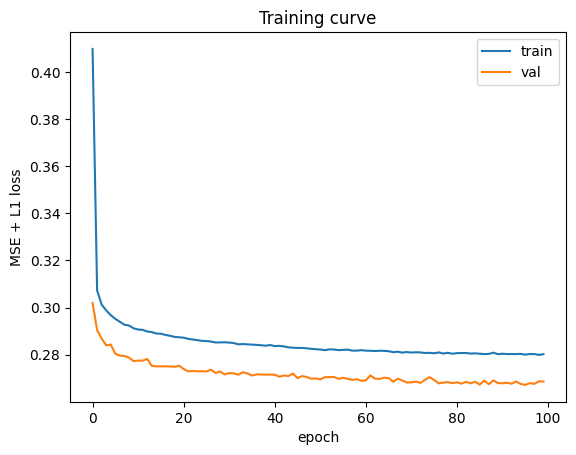

In [14]:
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('MSE + L1 loss')
plt.legend()
plt.title('Training curve')
plt.show()

## Sparsity check
How many gene-to-hidden connections actually survived the L1 penalty.

In [15]:
W1 = model.fc1.weight.detach().cpu().numpy()  # (hidden, genes)
near_zero_thresh = 1e-3
sparsity = (np.abs(W1) < near_zero_thresh).mean()
print(f'fc1 weight sparsity: {sparsity:.1%} of {W1.size:,} connections near-zero')
print(f'Mean nonzero connections per hidden unit: {(np.abs(W1) >= near_zero_thresh).sum(axis=1).mean():.1f} / {W1.shape[1]} genes')

fc1 weight sparsity: 80.8% of 133,888 connections near-zero
Mean nonzero connections per hidden unit: 401.9 / 2092 genes


## Per-protein evaluation -- train and test
Checking the relationship on both splits, not just held-out generalization -- a protein with a strong relationship should show consistent Pearson r/R2 across train and test, not just a high train fit.

In [22]:
X_rna[train_idx]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(48362, 2092), dtype=float32)

In [16]:
def evaluate_per_protein(model: nn.Module, X: np.ndarray, Y: np.ndarray,
                          protein_names: list[str], device: torch.device) -> pd.DataFrame:
    """Per-protein Pearson r and R2 for a full split."""
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X).to(device)).cpu().numpy()
    rows = []
    for i, name in enumerate(protein_names):
        r, _ = pearsonr(Y[:, i], preds[:, i])
        r2 = r2_score(Y[:, i], preds[:, i])
        rows.append({'protein': name, 'pearson_r': r, 'r2': r2})
    return pd.DataFrame(rows)


train_metrics = evaluate_per_protein(model, X_rna[train_idx], Y_protein[train_idx], matched_adt_names, DEVICE)
test_metrics  = evaluate_per_protein(model, X_rna[test_idx],  Y_protein[test_idx],  matched_adt_names, DEVICE)

metrics = train_metrics.merge(test_metrics, on='protein', suffixes=('_train', '_test'))
metrics['r_gap'] = metrics['pearson_r_train'] - metrics['pearson_r_test']
metrics = metrics.sort_values('pearson_r_test', ascending=False).reset_index(drop=True)

print(f"Median test Pearson r: {metrics['pearson_r_test'].median():.3f}")
print(f"Median train-test gap: {metrics['r_gap'].median():.3f}")
metrics.head(20)

Median test Pearson r: 0.451
Median train-test gap: 0.009


,protein,pearson_r_train,r2_train,pearson_r_test,r2_test,r_gap
0,AB_CD5,0.876969,0.768698,0.869823,0.756148,0.007146
1,AB_CD4,0.871856,0.758164,0.867817,0.751106,0.004039
2,AB_CD3,0.863270,0.744446,0.858320,0.735497,0.004950
3,AB_CD19,0.857930,0.735686,0.855978,0.732095,0.001952
4,AB_CD8,0.843026,0.707160,0.843956,0.709553,-0.000930
5,AB_CD21,0.833090,0.693939,0.829254,0.687603,0.003836
6,AB_CD2,0.834890,0.696986,0.826929,0.683523,0.007961
7,AB_FCGR2A,0.822811,0.675286,0.814747,0.661516,0.008063
8,AB_CD28,0.812925,0.660470,0.807944,0.652543,0.004981
9,AB_CR1,0.811726,0.656930,0.805778,0.647917,0.005948


## Gene importance per protein
Path-weight product through the sparse hidden layer approximates each gene's contribution to each protein -- no SHAP needed, the weights themselves are the explanation.

In [17]:
def compute_gene_importance(model: nn.Module, gene_names: list[str], protein_names: list[str]) -> pd.DataFrame:
    """|W2 @ W1| path-weight importance, shape (n_proteins, n_genes)."""
    W1 = model.fc1.weight.detach().cpu().numpy()  # (hidden, genes)
    W2 = model.fc2.weight.detach().cpu().numpy()  # (proteins, hidden)
    importance = np.abs(W2 @ W1)
    return pd.DataFrame(importance, index=protein_names, columns=gene_names)


importance_df = compute_gene_importance(model, gene_union, matched_adt_names)
importance_df.to_parquet(RESULTS_DIR / 'gene_protein_importance.parquet')
importance_df.shape

(163, 2092)

In [18]:
importance_df

,A4GALT,ABCA1,ABCB9,ABCC3,AC002558.2,AC003092.1,AC004408.1,AC004540.2,AC004585.1,AC005304.1,...,ZNF185,ZNF366,ZNF385A,ZNF385D,ZNF503,ZNF521,ZNF593,ZNF683,ZP3,ZWINT
AB_CD80,0.000007,0.000055,0.000296,0.003143,0.000028,0.000002,0.000023,0.000109,0.000415,0.000004,...,0.001957,0.000012,0.001720,0.000207,0.000766,0.000208,0.000531,0.007595,0.000642,0.000327
AB_CD86,0.000361,0.005139,0.000926,0.000753,0.000035,0.000072,0.000027,0.000040,0.003412,0.000158,...,0.002284,0.000377,0.002610,0.000504,0.001504,0.000563,0.001987,0.004030,0.001754,0.002739
AB_CD274,0.000136,0.000344,0.000088,0.003722,0.000026,0.000131,0.000170,0.000144,0.000831,0.000002,...,0.004495,0.000072,0.001331,0.000343,0.000935,0.000821,0.007197,0.002532,0.000016,0.000380
AB_PDCD1LG2,0.000027,0.000831,0.000024,0.002723,0.000043,0.000011,0.000025,0.000124,0.000567,0.000048,...,0.002524,0.000019,0.000707,0.000211,0.000532,0.000336,0.002253,0.003419,0.000127,0.000057
AB_ICOSLG,0.000111,0.000671,0.000267,0.003567,0.000096,0.000046,0.000066,0.000052,0.001143,0.000048,...,0.003617,0.000141,0.001805,0.000175,0.000800,0.000532,0.003062,0.005633,0.001049,0.000137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AB_Podocalyxin,0.000080,0.000334,0.000078,0.003116,0.000054,0.000067,0.000025,0.000058,0.000489,0.000032,...,0.003591,0.000003,0.000446,0.000313,0.000822,0.000216,0.001012,0.004029,0.000286,0.000466
AB_GGT1,0.000477,0.003879,0.001711,0.001163,0.000074,0.000119,0.000154,0.000164,0.000244,0.000126,...,0.000800,0.000233,0.002840,0.000165,0.000476,0.000305,0.008359,0.005320,0.001161,0.001885
AB_c-Met,0.000114,0.000173,0.000187,0.004993,0.000074,0.000053,0.000059,0.000105,0.000667,0.000078,...,0.003032,0.000051,0.001337,0.000261,0.001111,0.000343,0.000781,0.012854,0.001117,0.000018
AB_LIGHT,0.000079,0.000468,0.000331,0.002447,0.000054,0.000044,0.000072,0.000071,0.000548,0.000006,...,0.002901,0.000074,0.001497,0.000090,0.000560,0.000302,0.002519,0.002283,0.000492,0.000002


## Cognate gene rank
For each protein, where does its own cognate RNA rank among all 2092 genes by importance? Rank 1 means the cognate RNA is the top predictor; a high rank means something else -- a complex partner or tissue-proxy gene -- dominates instead.

In [19]:
def cognate_gene_rank(importance_df: pd.DataFrame, gene_map: pd.DataFrame) -> pd.DataFrame:
    """Rank of each protein's cognate RNA gene by importance score (1 = top predictor)."""
    rows = []
    for _, row in gene_map.iterrows():
        gene, adt = row['gene'], row['adt_name']
        if adt not in importance_df.index or gene not in importance_df.columns:
            continue
        ranks = importance_df.loc[adt].rank(ascending=False)
        top_gene = importance_df.loc[adt].idxmax()
        rows.append({
            'protein': adt,
            'cognate_gene': gene,
            'cognate_rank': int(ranks[gene]),
            'n_genes': len(ranks),
            'top_predictor_gene': top_gene,
        })
    return pd.DataFrame(rows).sort_values('cognate_rank').reset_index(drop=True)


cognate_ranks = cognate_gene_rank(importance_df, gene_map)
print(f"Proteins where cognate RNA is the #1 predictor: {(cognate_ranks['cognate_rank'] == 1).sum()} / {len(cognate_ranks)}")
cognate_ranks.head(20)

Proteins where cognate RNA is the #1 predictor: 6 / 163


,protein,cognate_gene,cognate_rank,n_genes,top_predictor_gene
0,AB_CD123,IL3RA,1,2092,IL3RA
1,AB_CD161,KLRB1,1,2092,KLRB1
2,AB_KLRG1,KLRG1,1,2092,KLRG1
3,AB_CD20,MS4A1,1,2092,MS4A1
4,AB_FcERIa,FCER1A,1,2092,FCER1A
5,AB_KIR3DL1,KIR3DL1,1,2092,KIR3DL1
6,AB_CD3,CD3D,2,2092,EEF1A1
7,AB_CD16,FCGR3A,2,2092,HBB
8,AB_CD62L,SELL,2,2092,EEF1A1
9,AB_CCR4,CCR4,2,2092,ITGA4


## Save results

In [20]:
metrics.to_csv(RESULTS_DIR / 'per_protein_metrics.csv', index=False)
cognate_ranks.to_csv(RESULTS_DIR / 'cognate_gene_ranks.csv', index=False)

print(f'Saved to {RESULTS_DIR}')
print(f'  per_protein_metrics.csv    -- {len(metrics)} proteins, train/test Pearson r + R2')
print(f'  cognate_gene_ranks.csv     -- cognate RNA rank per protein')
print(f'  gene_protein_importance.parquet -- {importance_df.shape[0]} x {importance_df.shape[1]} full importance matrix')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp
  per_protein_metrics.csv    -- 163 proteins, train/test Pearson r + R2
  cognate_gene_ranks.csv     -- cognate RNA rank per protein
  gene_protein_importance.parquet -- 163 x 2092 full importance matrix
